# General Conference Analysis - Interactive Exploration

This notebook demonstrates:
1. Scraping and caching conference talks
2. Temporal analysis of word/phrase trends
3. Embeddings-based semantic analysis
4. Topic clustering and visualization

## Understanding Embeddings

**Embeddings** are vector representations of text that capture semantic meaning. Think of them as coordinates in a high-dimensional space where:
- Similar concepts are close together
- Different concepts are far apart
- Mathematical operations can reveal relationships

For example:
- "faith" and "belief" will be close in embedding space
- "faith" and "automobile" will be far apart
- You can search by meaning, not just keywords

In [ ]:
# Import libraries
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date

# Import our custom modules
from conference_analysis.scraper import ConferenceScraper
from conference_analysis.temporal_analysis import TemporalAnalyzer
from conference_analysis.embeddings import EmbeddingsAnalyzer

# Set up plotting
sns.set_style('whitegrid')
%matplotlib inline

# Configure Plotly for Jupyter
import plotly.io as pio
pio.renderers.default = 'notebook'

# If plots don't display, try one of these instead:
# pio.renderers.default = 'jupyterlab'  # For JupyterLab
# pio.renderers.default = 'browser'     # Opens in browser
# Or use: fig.write_html('plot.html')   # Save to file

print("✅ Libraries imported successfully!")

## Step 1: Load Conference Talks

Loading talks from cache (already scraped and saved).

**Note**: 
- First time setup already completed - 4,890 talks cached from 1971-2025
- To update with new talks, uncomment the `update_cache()` line in the next cell
- Full scraping would take 30-60 minutes, but cache loading is instant!

In [ ]:
# Load cached talks (instant!)
scraper = ConferenceScraper(cache_file='../data/raw/talks.csv')
talks = scraper.talks_df

# If you want to check for new talks since last scrape, uncomment:
# talks = scraper.update_cache(delay=1.0)

print(f"\n✅ Loaded {len(talks)} talks from cache")
print(f"Date range: {talks['date'].min()} to {talks['date'].max()}")
print(f"\nSample talks:")
talks[['date', 'speaker', 'title']].head(10)

## Step 2: Temporal Analysis - Word and Phrase Trends

Track how specific words and phrases change in frequency over time.

In [5]:
# Initialize temporal analyzer
temporal = TemporalAnalyzer(talks)

# Track specific words over time
words_to_track = ['faith', 'hope', 'charity', 'love', 'service', 'obedience']

# Create interactive plot
fig = temporal.plot_word_trends(
    words_to_track,
    time_grouping='decade',
    normalize=True,
    interactive=True
)
fig.show()

In [6]:
# Track phrases over time
phrases_to_track = [
    'plan of salvation',
    'first vision',
    'book of mormon',
    'temple work'
]

fig = temporal.plot_phrase_trends(
    phrases_to_track,
    time_grouping='decade',
    normalize=True,
    interactive=True
)
fig.show()

In [7]:
# Compare different decades
unique_1970s, unique_2020s, common = temporal.compare_periods(1970, 2020, time_grouping='decade')

print("Top words unique to 1970s:")
print(unique_1970s[:15])
print("\nTop words unique to 2020s:")
print(unique_2020s[:15])
print("\nCommon words:")
print(common[:15])

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/claynoyes/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Top words unique to 1970s:
['priesthood', 'great', 'first', 'shall', 'upon']

Top words unique to 2020s:
['faith', 'power', 'love', 'savior', 'family']

Common words:
['life', 'children', 'people', 'would', 'know', 'gospel', 'president', 'many', 'church', 'world', 'said', 'come', 'unto', 'time', 'things']


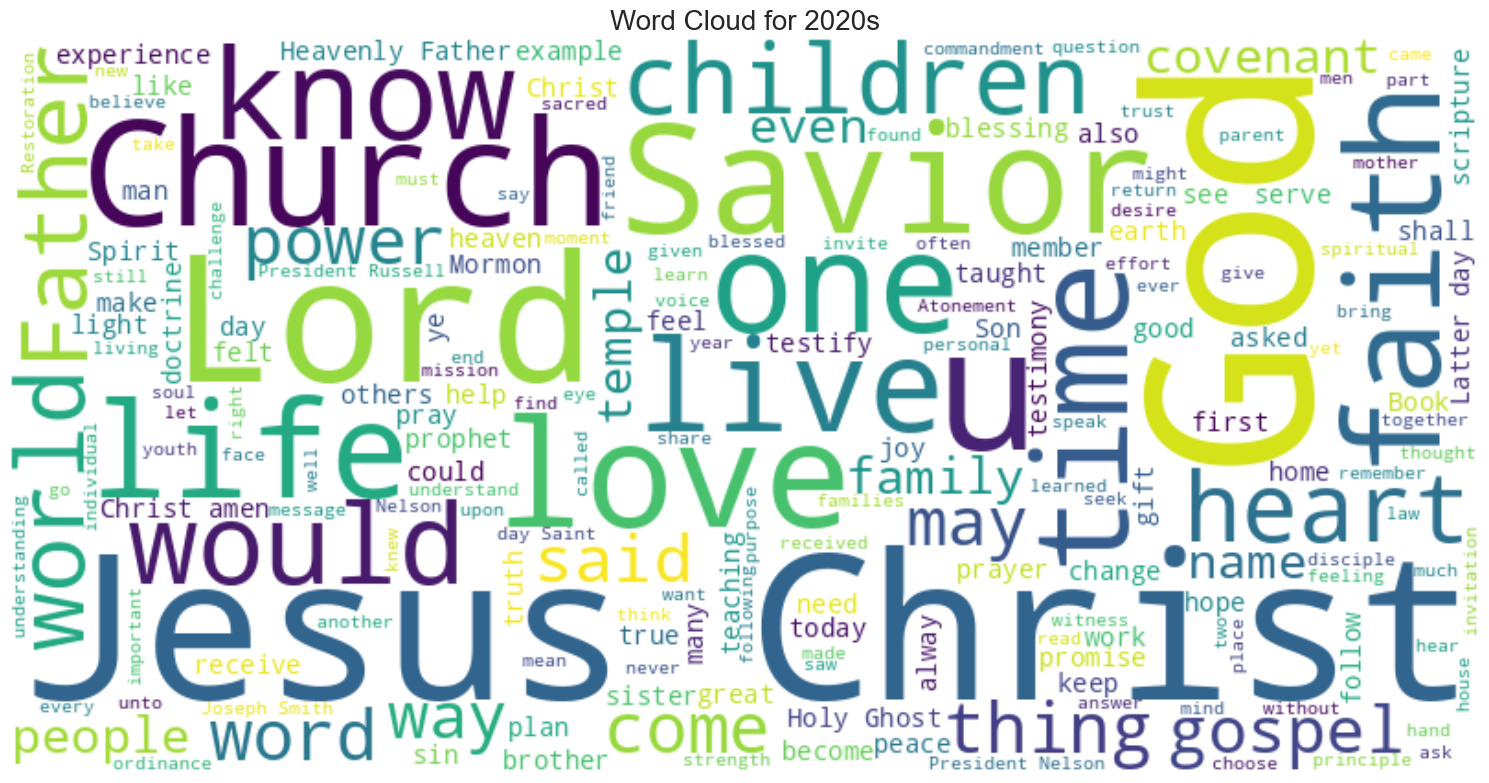

In [8]:
# Generate word cloud for a specific decade
wordcloud = temporal.wordcloud_by_period(2020, time_grouping='decade')

plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for 2020s', fontsize=20)
plt.tight_layout()
plt.show()

## Step 3: Embeddings Analysis - Semantic Understanding

This section demonstrates the power of embeddings for deeper semantic analysis.

### What are we doing here?
1. Converting each talk into a vector (embedding) that captures its meaning
2. Using cosine similarity to find talks with similar meanings
3. Clustering talks by their semantic content
4. Visualizing the semantic space in 2D

In [ ]:
# Initialize embeddings analyzer
# Using 'all-MiniLM-L6-v2' - a fast, efficient model
# For better quality (but slower), try 'all-mpnet-base-v2'

embeddings = EmbeddingsAnalyzer(
    talks,
    model_name='all-MiniLM-L6-v2',
    cache_dir='../data/processed'
)

# Generate embeddings (loads from cache if available, otherwise generates)
print("Loading embeddings...")
embeddings.generate_embeddings()
print("✅ Embeddings ready!")

### Semantic Search - Find by Meaning, Not Keywords

Traditional search matches keywords. Semantic search matches **meaning**.

Try searching for concepts, not just words!

In [10]:
# Semantic search example
query = "overcoming trials and adversity"

results = embeddings.semantic_search(query, top_k=10)

print(f"Top talks related to: '{query}'\n")
for idx, row in results.iterrows():
    print(f"{row['similarity']:.3f} - {row['title']}")
    print(f"          by {row['speaker']} ({row['date'].year})")
    print()

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Top talks related to: 'overcoming trials and adversity'

0.591 - Adversity and You
          by Marvin J. Ashton (1980)

0.567 - More Than Conquerors through Him That Loved Us
          by Paul V. Johnson (2011)

0.551 - “With God Nothing Shall Be Impossible”
          by Russell M. Nelson (1988)

0.547 - Tested and Tempted—but Helped
          by Hugo Montoya (2015)

0.501 - Facing Trials with Optimism
          by Anne Marie Rose (1996)

0.485 - Focus on Jesus Christ
          by Milton Camargo (2023)

0.479 - Adversity and Prayer
          by H. Burke Peterson (1973)

0.478 - Let Him Do It with Simplicity
          by L. Tom Perry (2008)

0.460 - Trust in the Lord
          by Richard G. Scott (1995)

0.456 - Adversity
          by Henry B. Eyring (2009)



In [11]:
# Try your own searches!
# Examples:
# - "raising faithful children"
# - "finding peace in difficult times"
# - "the importance of forgiveness"
# - "service and charity"

my_query = "the power of prayer"
results = embeddings.semantic_search(my_query, top_k=5)
print(results[['speaker', 'title', 'similarity']])

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

               speaker                   title  similarity
2885    James E. Faust  The Lifeline of Prayer    0.661764
2886    James E. Faust  The Lifeline of Prayer    0.661764
2821   Henry B. Eyring                  Prayer    0.639810
724   Howard W. Hunter  “Hallowed Be Thy Name”    0.604752
899     Boyd K. Packer     Prayers and Answers    0.602980


### Find Similar Talks

Given one talk, find others that discuss similar themes.

In [12]:
# Pick a random talk and find similar ones
random_talk_idx = np.random.randint(0, len(talks))
reference_talk = talks.iloc[random_talk_idx]

print(f"Reference talk:")
print(f"  {reference_talk['title']}")
print(f"  by {reference_talk['speaker']} ({reference_talk['date'].year})")
print(f"\nSimilar talks:\n")

similar = embeddings.find_similar_talks(random_talk_idx, top_k=5)
for idx, row in similar.iterrows():
    print(f"{row['similarity']:.3f} - {row['title']}")
    print(f"          by {row['speaker']} ({row['date'].year})")
    print()

Reference talk:
  Cleave unto the Covenants
  by Barbara Thompson (2011)

Similar talks:

1.000 - Cleave unto the Covenants
          by Barbara Thompson (2011)

0.688 - Gospel Covenants Bring Promised Blessings
          by Paul E. Koelliker (2005)

0.665 - Covenants with God Strengthen, Protect, and Prepare Us for Eternal Glory
          by Jean B. Bingham (2022)

0.656 - “Search Me, O God, and Know My Heart”
          by James E. Faust (1998)

0.654 - When You Save a Girl, You Save Generations
          by Mary N. Cook (2013)



### Topic Clustering

Automatically discover natural groupings of talks based on their content.
This reveals recurring themes across all of General Conference.

In [13]:
# Cluster talks into topics
n_clusters = 15
clustered = embeddings.cluster_talks(n_clusters=n_clusters)

# Examine each cluster
for cluster_id in range(n_clusters):
    summary = embeddings.get_cluster_summary(clustered, cluster_id, top_n=5)
    
    print(f"\n{'='*60}")
    print(f"CLUSTER {cluster_id} ({summary['size']} talks)")
    print(f"{'='*60}")
    
    print("\nMost representative talks:")
    for talk in summary['representative_talks'][:5]:
        print(f"  - {talk['title']}")
        print(f"    by {talk['speaker']}")
    
    print("\nTop speakers in this cluster:")
    for speaker, count in list(summary['top_speakers'].items())[:3]:
        print(f"  - {speaker}: {count} talks")

INFO:conference_analysis.embeddings:Clustering 4890 talks into 15 clusters...
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
/Users/claynoyes/.pyenv/versions/3.11.9/lib/python3.11/site-packages/threadpoolctl.py:1226: RuntimeWarning:


Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md




IndexError: index 4892 is out of bounds for axis 0 with size 4890

### Visualize the Semantic Space

See how talks relate to each other in 2D space.
Talks that are close together discuss similar themes.

In [14]:
# Visualize embeddings colored by decade
# Sample 1000 talks for faster visualization
fig = embeddings.visualize_embeddings_2d(
    color_by='decade',
    sample_size=1000,
    method='pca'
)
fig.show()

# You can interact with this plot:
# - Hover over points to see talk details
# - Zoom in on clusters
# - See how talks from different decades are distributed

INFO:conference_analysis.embeddings:Reducing embeddings to 2D using pca...


### Temporal Semantic Analysis

Combine embeddings with temporal analysis to see how discussion of a concept evolves.

In [15]:
# Track how talks about "faith" have evolved
time_periods = [
    (1970, 1979),
    (1980, 1989),
    (1990, 1999),
    (2000, 2009),
    (2010, 2019),
    (2020, 2024)
]

evolution = embeddings.temporal_semantic_shift(
    concept="faith and belief in God",
    time_periods=time_periods,
    top_k=5
)

# Show top talks per period
for period in evolution['period'].unique():
    print(f"\n{'='*60}")
    print(f"Period: {period}")
    print(f"{'='*60}")
    period_talks = evolution[evolution['period'] == period]
    for idx, row in period_talks.iterrows():
        print(f"  {row['similarity']:.3f} - {row['title']}")
        print(f"            by {row['speaker']}")

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Period: 1970-1979
  0.529 - A Basis for Faith in the Living God
            by N. Eldon Tanner
  0.529 - A Basis for Faith in the Living God
            by N. Eldon Tanner
  0.518 - “Come Home, Felila”
            by John H. Groberg
  0.494 - The Cs of Spirituality
            by Robert E. Wells
  0.477 - Faith and Works in the Far East
            by Adney Y. Komatsu

Period: 1980-1989
  0.615 - Building Bridges to Faith
            by Loren C. Dunn
  0.533 - He Is There
            by N. Eldon Tanner
  0.521 - Jesus Christ: Our Savior and Redeemer
            by Ezra Taft Benson
  0.481 - Developing Faith
            by A. Theodore Tuttle
  0.473 - “We Believe in Being Honest”
            by Mark E. Petersen

Period: 1990-1999
  0.578 - Faith Is the Answer
            by Virginia H. Pearce
  0.578 - Faith Is the Answer
            by Virginia H. Pearce
  0.510 - Faith of Our Fathers
            by Joseph B. Wirthlin
  0.503 - Making Faith a Reality
            by Janette Hales Beckh

## Step 4: Custom Analysis

Use the cells below for your own exploration!

In [ ]:
# Your custom analysis here


## Next Steps

Ideas for further exploration:

1. **Speaker Analysis**: Track how individual speakers' themes evolve over their ministry
2. **Topic Modeling**: Use LDA or BERTopic for more sophisticated topic discovery
3. **Sentiment Analysis**: Analyze emotional tone across different time periods
4. **Network Analysis**: Build a network of related talks and speakers
5. **Predictive Analysis**: Train models to predict which talks will be most impactful
6. **Web Dashboard**: Build an interactive Streamlit or Plotly Dash app

## Learning Resources

To learn more about embeddings and NLP:

- [Sentence Transformers Documentation](https://www.sbert.net/)
- [Understanding Word Embeddings](https://jalammar.github.io/illustrated-word2vec/)
- [Hugging Face NLP Course](https://huggingface.co/learn/nlp-course/chapter1/1)
- [Fast.ai NLP Course](https://www.fast.ai/)